In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import pycountry
import pycountry_convert as pc

In [2]:
pd.set_option('display.max_columns', None) # To display all columns
pd.set_option('display.max_rows', 200) # To display at most 200 rows

In [3]:
def load_csv(path)-> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    print(f"CSV file loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns")
    return df


df = load_csv("../Dataset/raw/Life Expectancy Data.csv")

CSV file loaded successfully with 2938 rows and 22 columns


In [4]:
df.head(3)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


# Life Expectancy Dataset Analysis

## Dataset Description
This dataset contains health-related, socioeconomic, and demographic data for various countries over several years, sourced from the World Health Organization (WHO) and the United Nations [3, 4]. It's ideal for analyzing factors influencing longevity.

## Data Source
*   **Source:** World Health Organization (WHO) & United Nations [3, 4].
*   **Availability:** {Link: Kaggle https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who} [4].

## Variables/Features (Columns)
*   `Country`: Name of the country.
*   `Year`: Year of observation.
*    `Status`: Whether the country is developed or developing
*   `Life_expectancy`: (Target Variable) Average years a person can expect to live from birth.
*   `Adult_mortality`: Adult mortality rate (per 1000 live births).
*    `alcohol`: Average alcohol consumption per adult
*    `percentage_expenditure`: Government or individuals' health expenditure relative to GDP, expressed as a percentage.
*   `BMI`: Body Mass Index average.
*   `Schooling`: Average years of schooling.
*   `Health_expenditure`: Per capita expenditure on health.
*    `hepatitis_b`: Percentage of 1-year-olds vaccinated against Hepatitis B.
* `measles`: Number of reported measles cases per 1,000 population.

*   `GDP`: Gross Domestic Product per capita.
*   `Infant_deaths`: Number of infant deaths.
*   `under-five_deaths`: Number of deaths of children under 5 years old per 1,000 population.
*   `Diphtheria`: Percentage of 1-year-olds vaccinated against Diphtheria, Pertussis, and Tetanus (DPT).
*  `polio`: Percentage of 1-year-olds vaccinated against Polio.
*  `total_expenditure`: Government health expenditure as a percentage of total government spending.
*   `population`: Total population of the country for that year.
*   `thinness__1-19_years`: Percentage of adolescents (ages 10–19) who are underweight.
*   `thinness_5-9_years`: Percentage of children ages 5–9 who are underweight.
*   `income_composition_of_resources`: A Human Development Index (HDI) component.
*   `schooling`: Average number of years of school an individual aged 25+ has attended.



## Analysis Goals
*   Predict life expectancy at birth using machine learning models (Regression).
*   Identify key predictors (e.g., GDP, mortality, education) affecting life expectancy [3, 4].
*   Analyze trends over time and across different regions/countries.

## Usage/Examples
*   Preprocess data (handle missing values, scale features).
*   Train models (Linear Regression, Random Forest, etc.) [1, 4].
*   Visualize correlations and predictions.

## File Structure
*   `Life_Expectancy_Data.csv`: The main dataset file [1, 15].
*   `Analysis_Notebook.ipynb`: Jupyter notebook for exploration and modeling [1].


The data-set aims to answer the following key questions:

* Does various predicting factors which has been chosen initially really affect the Life expectancy?
* What are the predicting variables actually affecting the life expectancy?
* Should a country having a lower life expectancy value(<65) increase its healthcare expenditure in order to improve its average lifespan?
* How does Infant and Adult mortality rates affect life expectancy?
* Does Life Expectancy has positive or negative correlation with eating habits, lifestyle, exercise, smoking, drinking alcohol etc.
* What is the impact of schooling on the lifespan of humans?
* Does Life Expectancy have positive or negative relationship with drinking alcohol?
* Do densely populated countries tend to have lower life expectancy?
What is the impact of Immunization coverage on life Expectancy?

In [5]:
df.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


- Which countries has the highest infant and under-five_deaths, any confounding variables with the feature
- Countries/continents  with  low  total expenditure
- **bmi,polio,measles, diphtheria ratio vs life expectation**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2938 non-null   object 
 1   year                             2938 non-null   int64  
 2   status                           2938 non-null   object 
 3   life_expectancy                  2928 non-null   float64
 4   adult_mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   hepatitis_b                      2385 non-null   float64
 9   measles                          2938 non-null   int64  
 10  bmi                              2904 non-null   float64
 11  under-five_deaths                2938 non-null   int64  
 12  polio               

In [7]:
print(df.isnull().sum().sort_values(ascending=False))
print(f"\nNumber of records: {df.shape[0]}\nNumber of features: {df.shape[1]}")

population                         652
hepatitis_b                        553
gdp                                448
total_expenditure                  226
alcohol                            194
income_composition_of_resources    167
schooling                          163
thinness__1-19_years                34
thinness_5-9_years                  34
bmi                                 34
diphtheria                          19
polio                               19
life_expectancy                     10
adult_mortality                     10
infant_deaths                        0
status                               0
country                              0
year                                 0
under-five_deaths                    0
measles                              0
percentage_expenditure               0
hiv/aids                             0
dtype: int64

Number of records: 2938
Number of features: 22


life_expextancy, adult_mortality, bmi, polio, diphtheria, thinness__1-19_years, thinness__5-9_years

In [8]:
drop_rows = ['life_expectancy', 'adult_mortality', 'bmi', 'diphtheria',
           'polio', 'thinness__1-19_years', 'thinness_5-9_years']

df = df.dropna(subset=drop_rows)
df.isnull().sum().sort_values(ascending=False)

population                         644
hepatitis_b                        525
gdp                                435
total_expenditure                  212
alcohol                            175
income_composition_of_resources    160
schooling                          160
adult_mortality                      0
infant_deaths                        0
status                               0
year                                 0
country                              0
life_expectancy                      0
percentage_expenditure               0
polio                                0
under-five_deaths                    0
bmi                                  0
measles                              0
diphtheria                           0
hiv/aids                             0
thinness_5-9_years                   0
thinness__1-19_years                 0
dtype: int64

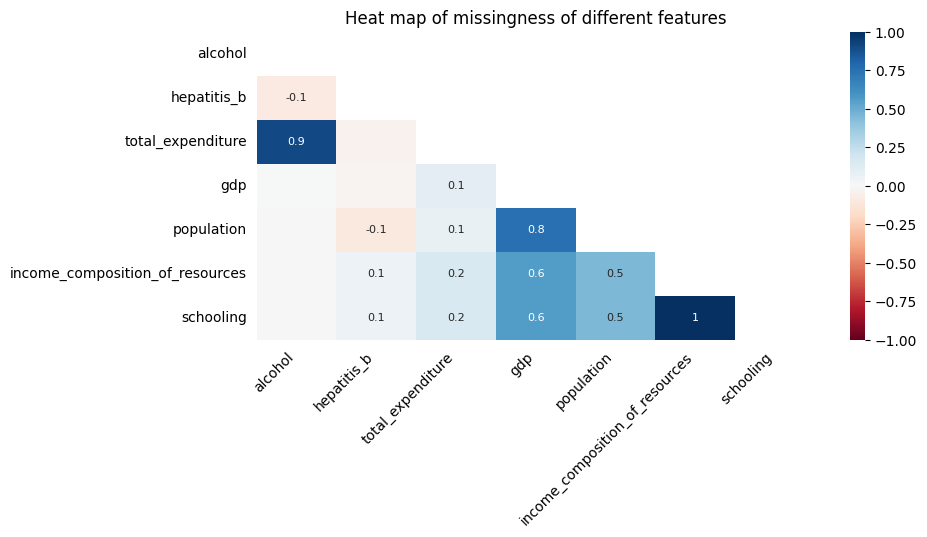

In [9]:
msno.heatmap(df, figsize=(9,4), fontsize=10);
plt.title("Heat map of missingness of different features");

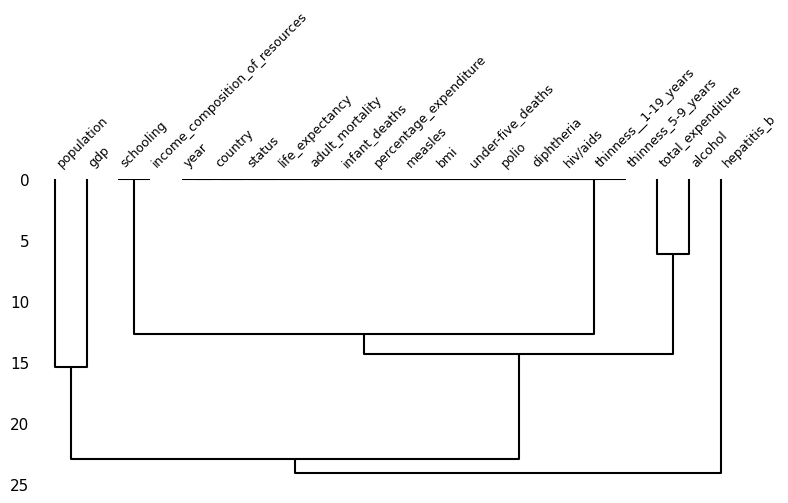

In [10]:
msno.dendrogram(df, figsize=(9,4), fontsize=9);

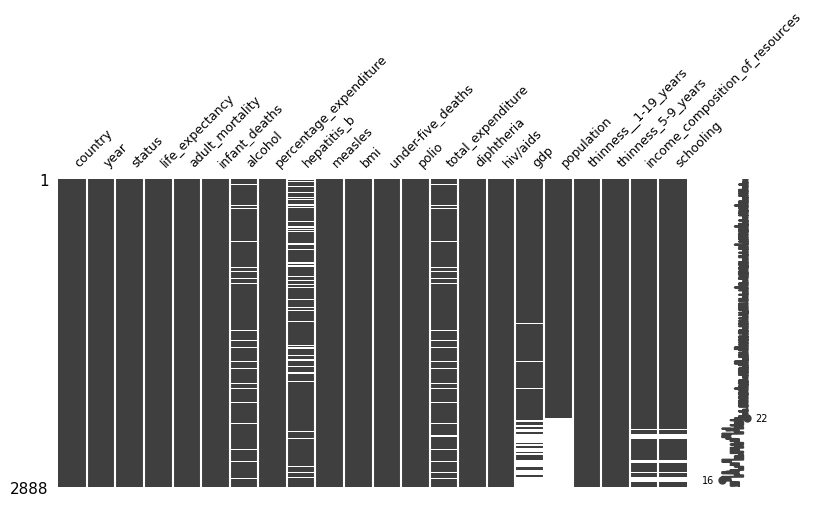

In [11]:
df_sorted = df.sort_values(by='population')
msno.matrix(df_sorted, figsize=(9,4), fontsize=9)
plt.show()

In [12]:
num_df = df.select_dtypes(include=['number'])

for i in num_df.columns:
    print((i.upper()).center(50,'~'))
    print(df[i].agg(['min', 'mean', 'median', 'std', 'max', 'skew']))
    print()

~~~~~~~~~~~~~~~~~~~~~~~YEAR~~~~~~~~~~~~~~~~~~~~~~~
min       2000.000000
mean      2007.515235
median    2008.000000
std          4.606938
max       2015.000000
skew        -0.003870
Name: year, dtype: float64

~~~~~~~~~~~~~~~~~LIFE_EXPECTANCY~~~~~~~~~~~~~~~~~~
min       36.300000
mean      69.349377
median    72.200000
std        9.495441
max       89.000000
skew      -0.663162
Name: life_expectancy, dtype: float64

~~~~~~~~~~~~~~~~~ADULT_MORTALITY~~~~~~~~~~~~~~~~~~
min         1.000000
mean      163.357341
median    143.000000
std       124.018934
max       723.000000
skew        1.208533
Name: adult_mortality, dtype: float64

~~~~~~~~~~~~~~~~~~INFANT_DEATHS~~~~~~~~~~~~~~~~~~~
min          0.000000
mean        30.314751
median       3.000000
std        118.891670
max       1800.000000
skew         9.715748
Name: infant_deaths, dtype: float64

~~~~~~~~~~~~~~~~~~~~~ALCOHOL~~~~~~~~~~~~~~~~~~~~~~
min        0.010000
mean       4.643830
median     3.810000
std        4.053529
max       17

In [13]:
object_df = df.select_dtypes(include=['object'])

def check_cat_columns(df):
    for column in df:
        print((column.upper()).center(37, '*'))
        print(df[column].agg(['nunique', 'count']))
        print(df[column].value_counts())
        print()

check_cat_columns(object_df)

***************COUNTRY***************
nunique     181
count      2888
Name: country, dtype: int64
country
Afghanistan                                             16
Albania                                                 16
Algeria                                                 16
Angola                                                  16
Antigua and Barbuda                                     16
Argentina                                               16
Armenia                                                 16
Australia                                               16
Austria                                                 16
Azerbaijan                                              16
Bahamas                                                 16
Bahrain                                                 16
Bangladesh                                              16
Barbados                                                16
Belarus                                                 16
Belgium  

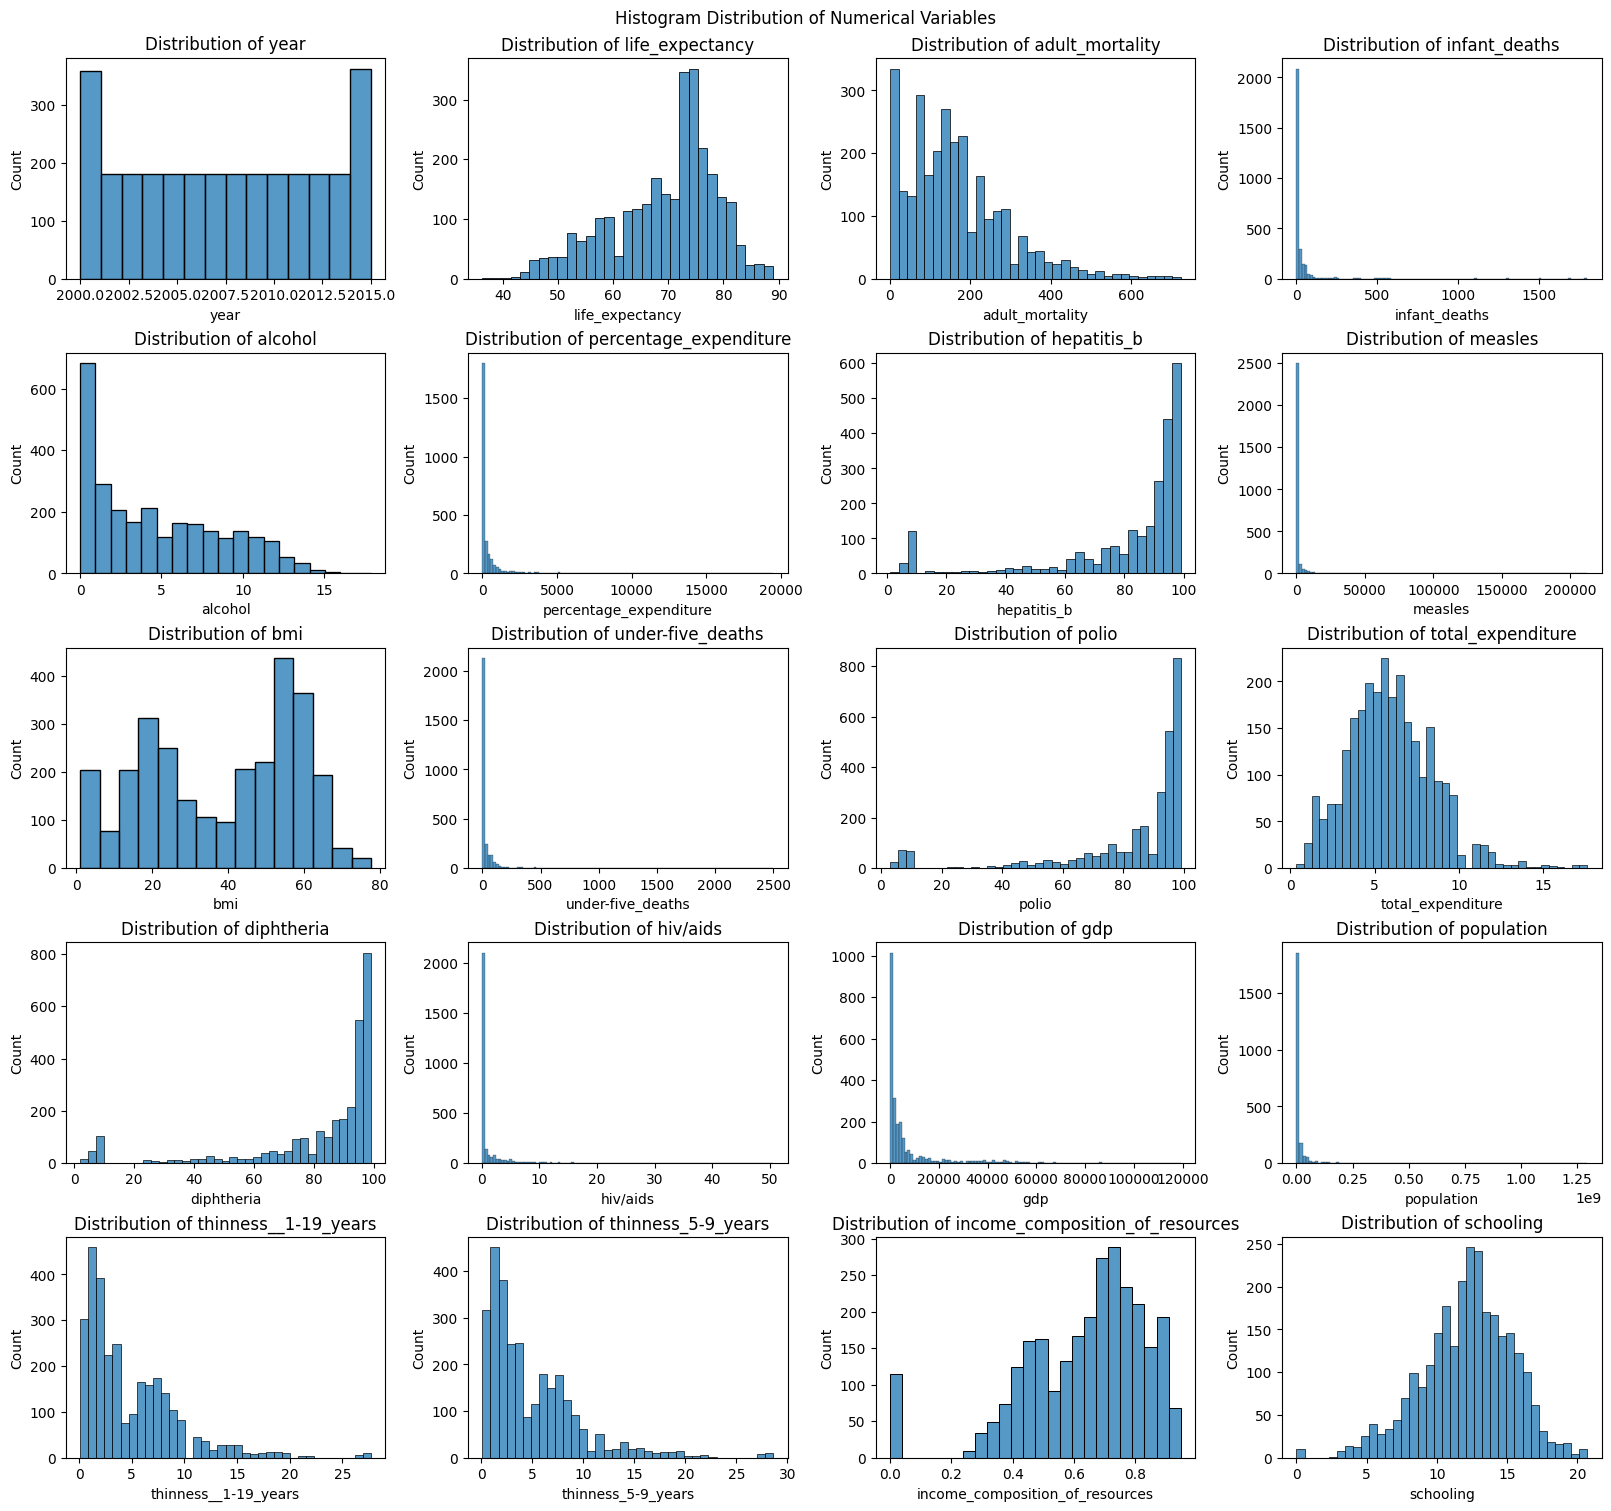

In [14]:
columns = len(num_df.columns)
n_cols = 4
n_rows = (columns + n_cols - 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(16, 3*n_rows))
axs = axs.flatten()
fig.suptitle('Histogram Distribution of Numerical Variables')
for i, col in enumerate(num_df.columns):
    sns.histplot(data=num_df, x=col, ax=axs[i])
    axs[i].set_title(f"Distribution of {col}")

plt.show()

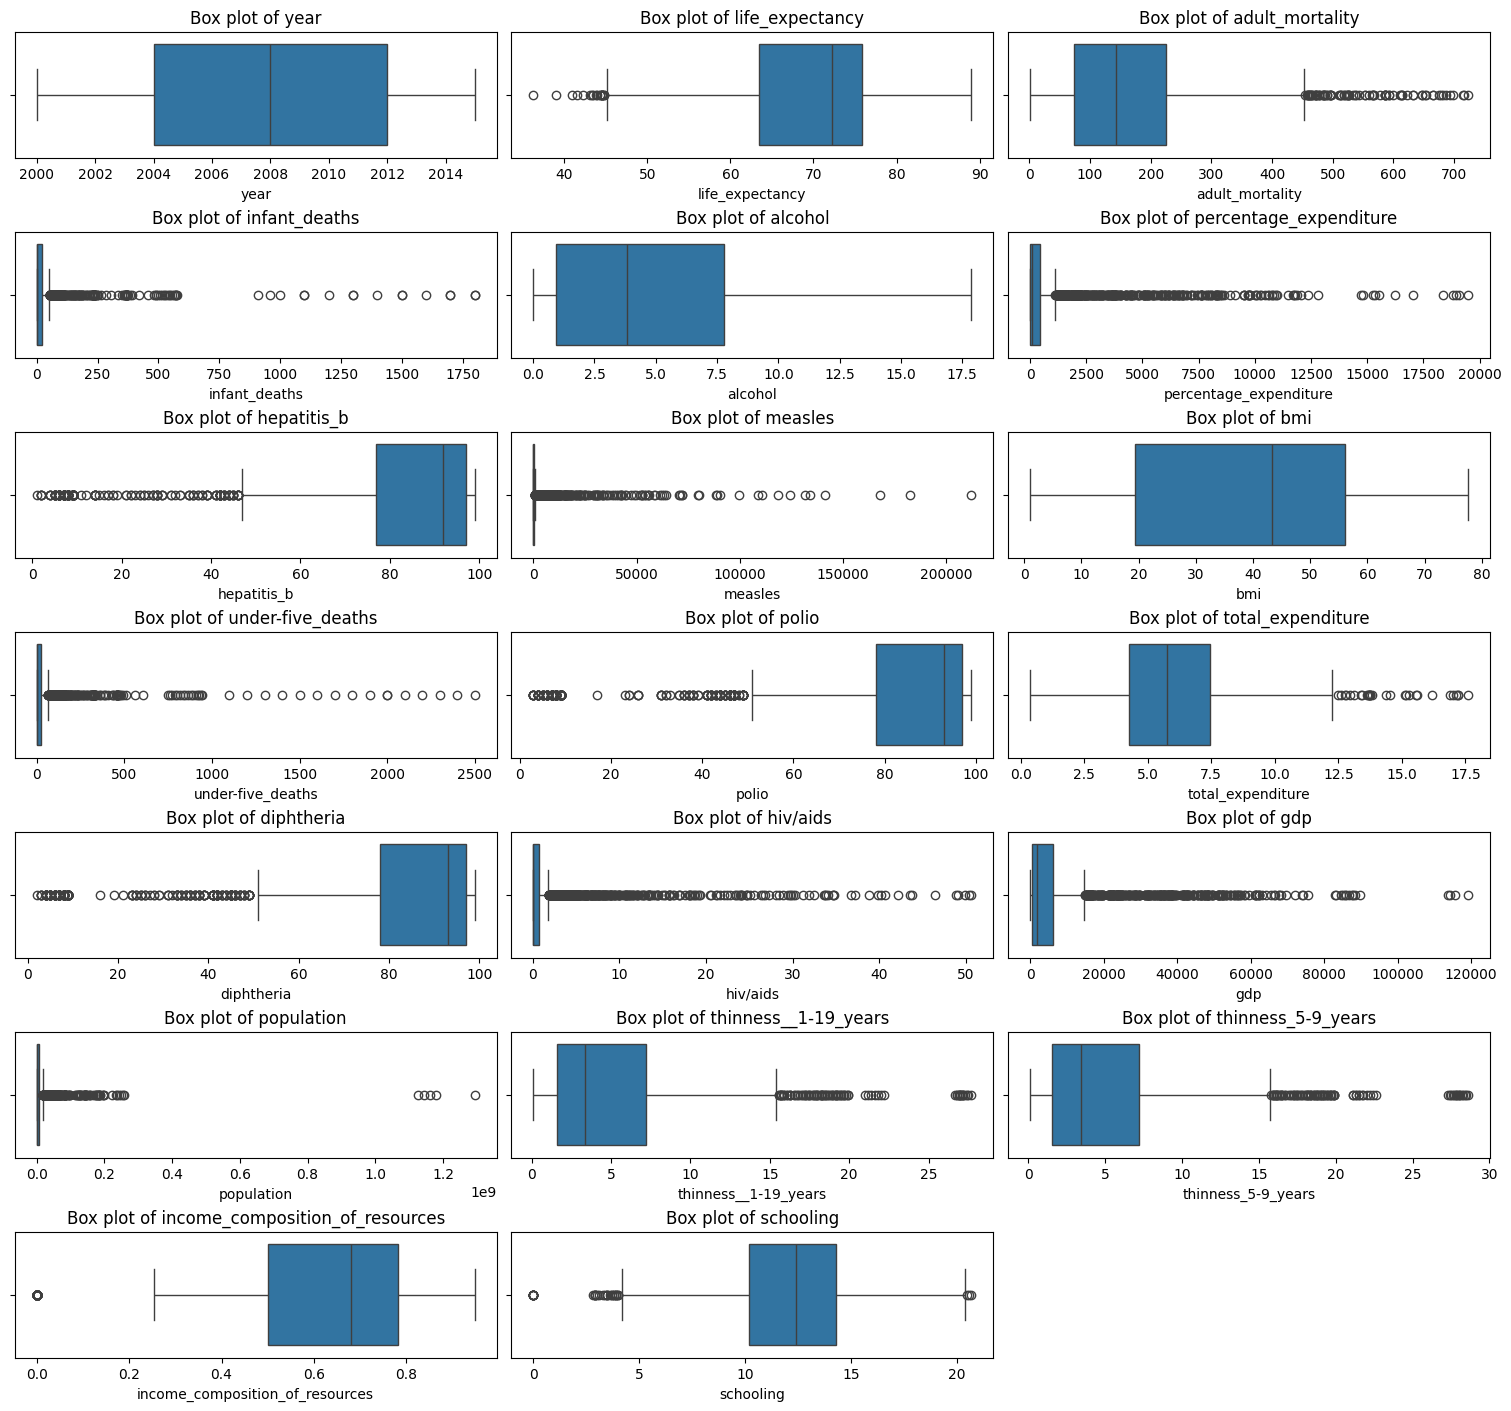

In [15]:
columns = len(num_df.columns)
n_col = 3
n_rows = (columns + n_col -1) // n_col

fig, axs = plt.subplots(n_rows, n_col, layout='constrained', figsize=(15, 2*n_rows))
axs = axs.flatten()

for i, col in enumerate(num_df):
    sns.boxplot(data=num_df, x=col, ax=axs[i])
    axs[i].set_title(f"Box plot of {col}")

for j in range(i+1, len(axs)):
    axs[j].set_visible(False)

plt.show()

colums like `infant_deaths`, `percentage_expenditure`, `hiv/aids`are highly skewed

In [16]:
num_df.columns

Index(['year', 'life_expectancy', 'adult_mortality', 'infant_deaths',
       'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi',
       'under-five_deaths', 'polio', 'total_expenditure', 'diphtheria',
       'hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling'],
      dtype='object')

In [17]:
highly_skewed_cols = ['infant_deaths',
      'percentage_expenditure', 'hepatitis_b', 'measles',
       'under-five_deaths', 'polio',  'diphtheria',
       'hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling']

# for col in highly_skewed_cols:
#     df['log_'+col] = np.log1p(df[col])

# df.corr(numeric_only=True)

In [18]:
df.sample(3, random_state=2)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
1890,Niger,2002,Developing,51.4,282.0,57,0.10,17.587227,NaN,31584,14.3,124,43.0,6.55,39.0,1.6,177.828384,12262.0,12.5,12.5,0.261,2.9
1809,Namibia,2002,Developing,55.7,452.0,3,5.09,203.732289,NaN,1278,25.8,4,78.0,6.17,77.0,24.6,1713.475940,1962147.0,14.7,14.8,0.556,11.8
158,Azerbaijan,2001,Developing,67.5,151.0,8,0.51,4.104190,NaN,574,42.6,10,77.0,4.48,77.0,0.1,73.683843,81112.0,3.1,3.1,0.642,10.4


In [19]:
def convert(row):
  '''Get the continent of the country
  Args:
  Returns:
    The continent where the country is found
    '''
  try:
    #convert the country name to country code
    country_code = pc.country_name_to_country_alpha2(row, cn_name_format="default")
    #convert the country code to continent code
    continent_code = pc.country_alpha2_to_continent_code(country_code)
    #convert the continent code to continent name
    return pc.convert_continent_code_to_continent_name(continent_code)
  except:
    return None


In [20]:
df['continent'] = df['country'].apply(convert)
df['continent'].value_counts(dropna=False)

continent
Africa           832
Asia             704
Europe           602
North America    336
South America    160
Oceania          144
None             110
Name: count, dtype: int64

In [21]:
countries_without_continent = df.loc[df['continent'].isna(), 'country'].unique().tolist()
countries_without_continent

['Bolivia (Plurinational State of)',
 'Iran (Islamic Republic of)',
 'Micronesia (Federated States of)',
 'Republic of Korea',
 'The former Yugoslav republic of Macedonia',
 'Timor-Leste',
 'Venezuela (Bolivarian Republic of)']

In [22]:
country_continent = {'Bolivia (Plurinational State of)': 'South America',
 'Iran (Islamic Republic of)': 'Asia',
 'Micronesia (Federated States of)': 'Oceania',
 'Republic of Korea':'Asia',
 'The former Yugoslav republic of Macedonia': 'Europe',
 'Timor-Leste': 'Asia',
 'Venezuela (Bolivarian Republic of)': 'South America'}

df['continent'] = df['continent'].fillna(df['country'].map(country_continent))

In [23]:
df['continent'].value_counts(dropna=False)

continent
Africa           832
Asia             750
Europe           618
North America    336
South America    192
Oceania          160
Name: count, dtype: int64

In [24]:
df.sample(7)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling,continent
556,Chile,2003,Developing,77.9,1.0,2,6.37,584.099343,NaN,1,56.1,2,96.0,7.34,96.0,0.1,4787.699532,15799542.0,1.0,1.0,0.775,14.0,South America
1968,Panama,2006,Developing,76.2,125.0,1,5.72,631.125171,88.0,0,51.1,2,98.0,7.00,88.0,0.1,5348.518399,339195.0,2.1,2.0,0.744,12.9,North America
2365,Solomon Islands,2011,Developing,68.5,186.0,0,0.99,229.668749,99.0,0,47.2,0,99.0,5.80,99.0,0.1,1642.837974,539614.0,1.2,1.2,0.497,9.4,Oceania
2396,South Africa,2012,Developing,59.2,48.0,43,7.38,1089.954838,68.0,32,48.7,56,65.0,8.79,65.0,7.6,7548.163698,5256515.8,6.0,7.3,0.644,12.8,Africa
315,Bolivia (Plurinational State of),2004,Developing,65.1,226.0,12,2.66,0.000000,84.0,0,45.4,16,84.0,5.22,84.0,0.2,NaN,NaN,1.4,1.2,0.620,14.6,South America
1481,Lesotho,2008,Developing,47.8,592.0,5,2.75,91.854328,88.0,0,28.8,6,86.0,8.85,88.0,27.3,934.428563,199993.0,8.0,7.8,0.447,10.7,Africa
1382,Kiribati,2011,Developing,65.5,26.0,0,0.53,30.467039,95.0,0,75.7,0,95.0,1.42,99.0,0.1,1692.613277,14656.0,0.1,0.1,0.585,11.9,Oceania


In [25]:
df['immunization'] = (df['diphtheria'] + df['hepatitis_b'] + df['measles'] + df['polio'])
df['mortality'] = df['adult_mortality'] + df['infant_deaths'] + df['under-five_deaths'] + df['hiv/aids']
df.head(2)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling,continent,immunization,mortality
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,Asia,1290.0,408.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,Asia,674.0,421.1


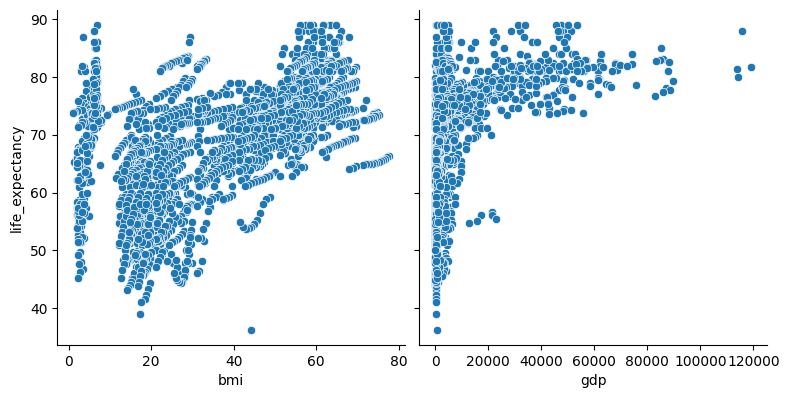

In [26]:
features = ['bmi', 'gdp']
target = ['life_expectancy']

sns.pairplot(df, x_vars=features, y_vars=target, kind='scatter', height=4)

## Life expectancy by continent

In [27]:
df.groupby('continent')[['life_expectancy']].mean().sort_values(by='life_expectancy')

,life_expectancy
continent,
Africa,58.641226
Oceania,71.214375
Asia,71.227067
South America,72.971875
North America,73.778869
Europe,77.470227


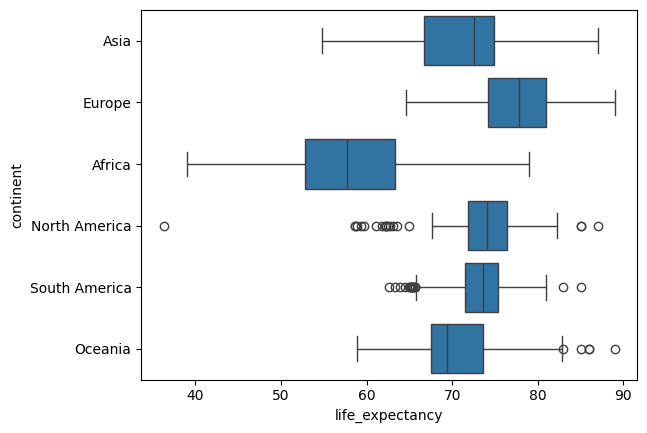

In [28]:
sns.boxplot(data=df, y='continent', x='life_expectancy')
plt.show()

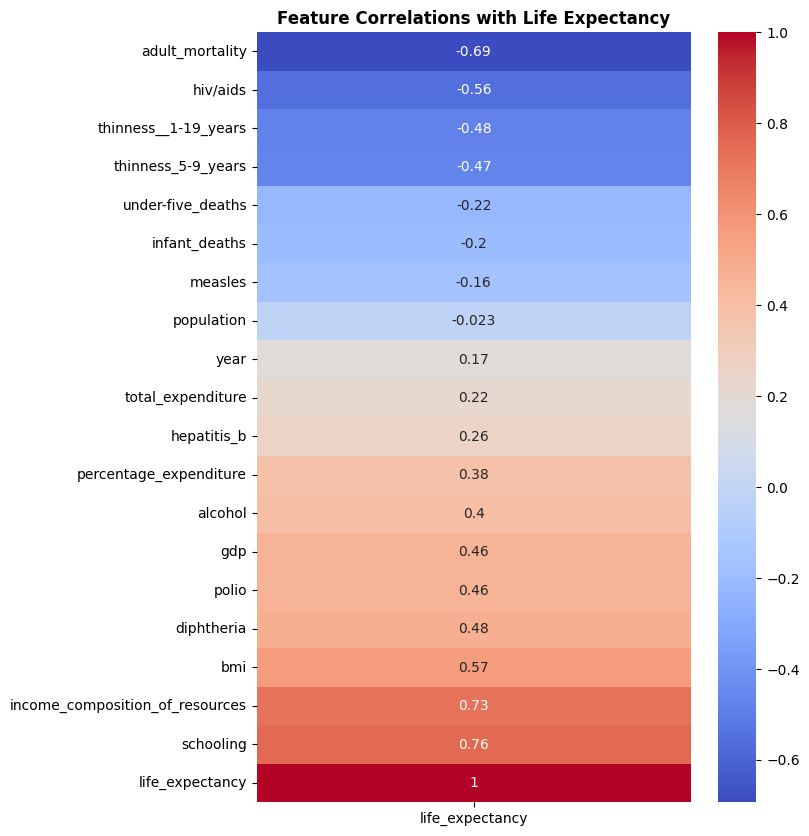

In [29]:
plt.figure(figsize=(7,10))
life_exp_corr = num_df.corr()[['life_expectancy']].sort_values(by='life_expectancy')
sns.heatmap(life_exp_corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlations with Life Expectancy", fontweight='bold')
plt.show()

In [30]:
df['schooling'].corr(df['population'])

np.float64(-0.03808261952934821)

### Correlation of Features with Life Expectancy

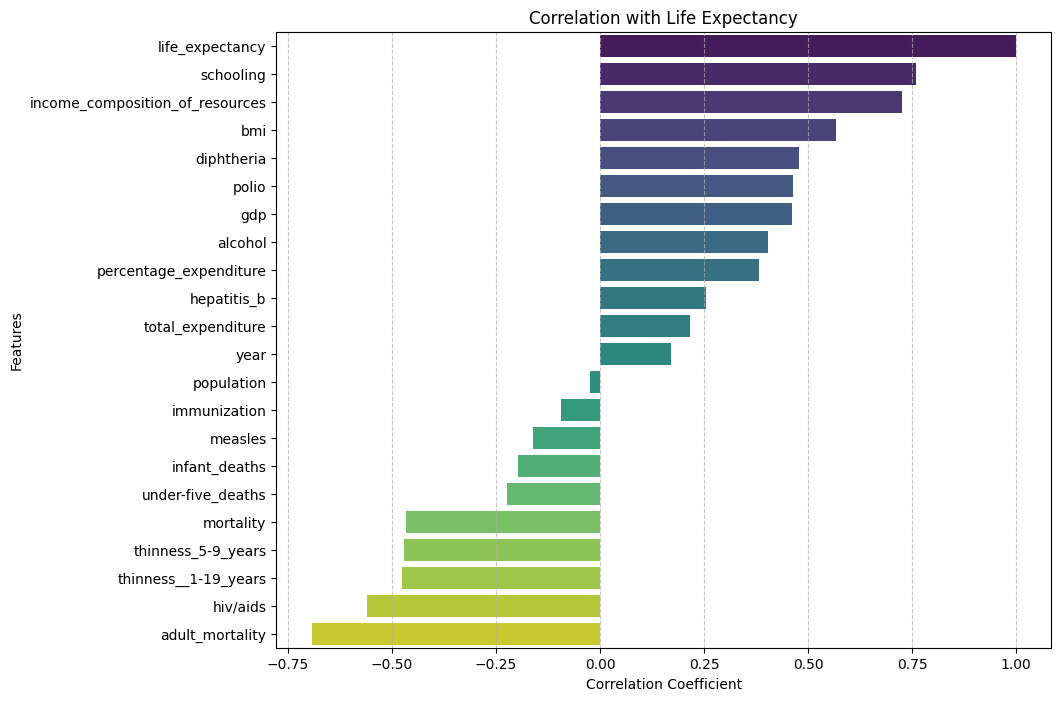

In [31]:
corr_with_life_expectancy = df.corr(numeric_only=True)[['life_expectancy']].sort_values(by='life_expectancy', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_life_expectancy['life_expectancy'],
            y=corr_with_life_expectancy.index, 
            palette='viridis',
            legend=False,
            hue=corr_with_life_expectancy.index)
plt.title('Correlation with Life Expectancy')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [32]:
df.groupby('continent')[['schooling']].mean().sort_values(by='schooling')

,schooling
continent,
Africa,9.430729
Asia,11.771170
North America,12.426875
Oceania,12.979375
South America,13.406771
Europe,15.318246


## Does population affect the life expectancy

The population column is highly skewed. Log transformation will be applied to it to reduce skewness and the population will be divided into categories for analysis

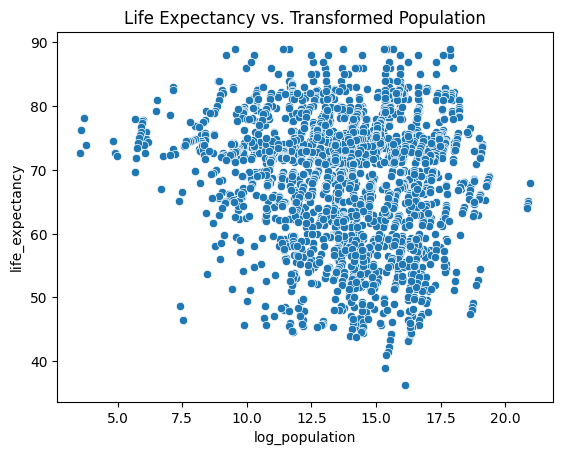

In [33]:
df['log_population'] = np.log(df['population']) #Transform the population column using log
sns.scatterplot(x=df['log_population'], y=df['life_expectancy'])
plt.title("Life Expectancy vs. Transformed Population")
plt.show()

Arranging the population into different bins

In [34]:
#(0,1_000_000], (1_000_000,50_000_000]
bins = [0,1e6, 50e6, 200e6, 2e9]
labels = ['small <1M', 'medium <50M', 'large <200M', 'mega <2B']
df['population_bins'] = pd.cut(df['population'], bins=bins, labels=labels)

In [35]:
df.groupby(['population_bins'])[['life_expectancy']].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_20508\883392860.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['population_bins'])[['life_expectancy']].mean()


,life_expectancy
population_bins,
small <1M,69.925756
medium <50M,67.768789
large <200M,69.898913
mega <2B,66.791667


## Should a country having a lower life expectancy value(<65) increase its healthcare expenditure in order to improve its average lifespan?

In [36]:
df['log_immunization'] = np.log(df['immunization'])

In [37]:
le_less_than_65 = df[df['life_expectancy'] < 65]
le_less_than_65[['total_expenditure', 'percentage_expenditure', 'log_immunization']].describe()

,total_expenditure,percentage_expenditure,log_immunization
count,764.000000,818.000000,567.000000
mean,5.355314,73.591659,6.537504
std,2.210716,170.889520,1.439315
min,0.650000,0.000000,3.091042
25%,3.897500,2.029857,5.602119
50%,5.000000,22.012859,5.991465
75%,6.520000,62.644879,7.244570
max,14.390000,1705.678619,11.805797


<Axes: xlabel='log_immunization', ylabel='life_expectancy'>

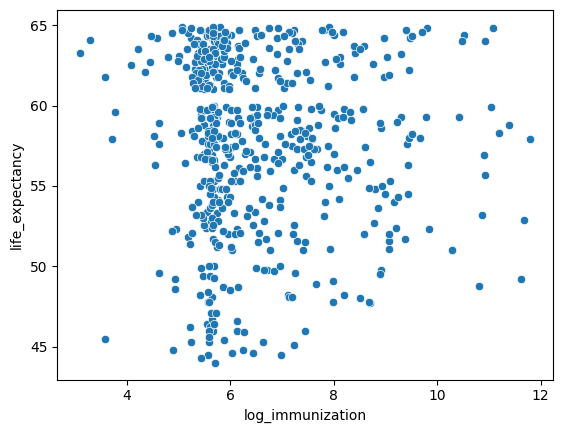

In [38]:
sns.scatterplot(x=le_less_than_65['log_immunization'], 
                y=le_less_than_65['life_expectancy'])

In [39]:
df.head(3)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling,continent,immunization,mortality,log_population,population_bins,log_immunization
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,Asia,1290.0,408.1,17.334091,medium <50M,7.162397
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,Asia,674.0,421.1,12.699494,small <1M,6.513230
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,Asia,620.0,423.1,17.272826,medium <50M,6.429719
